In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
np.set_printoptions(linewidth=np.inf)

In [38]:
fwhms = pd.DataFrame(columns=["n0", "n2", "values", "amplitudes"])

In [11]:
fwhms = pd.read_csv("fwhms_amps.csv", converters={"n0":complex, "n2":complex, "values":pd.eval, "amplitudes":pd.eval})
fwhms["values"] = fwhms["values"].map(lambda val: np.array(val))
fwhms["amplitudes"] = fwhms["amplitudes"].map(lambda val: np.array(val))

In [12]:
pd.set_option('display.float_format', '{:.2g}'.format)
fwhms[["n0", "n2"]]

,n0,n2
0,1+0j,0+0j
1,1+1e-06j,0+0j
2,1+1e-07j,0+0j
3,1+1e-08j,0+0j
4,1+5e-08j,0+0j
5,1-1e-08j,0+0j
6,1-1e-07j,0+0j
7,1-1e-06j,0+0j
8,1+0j,0+0.1j
9,1+0j,0+0.01j


In [30]:
params = {}
with open("params1.txt") as f:
    lines = f.readlines()
    for item in lines:
        item = item.split()
        params[item[0]] = float(item[1])
n0 = params['n0_real'] +1j*params["n0_imag"]
n2 = params['n2_real'] +1j*params["n2_imag"]
lambda_0 = params['wavelength']
w0 = params['w0']
print(w0)
amp_0 = params["amplitude"]  # starting amplitude
gamma = np.sqrt(n2/n0)
propagation_length = params["propagation_length"]
steps = params["steps"]
step_size = propagation_length/steps
# A = np.cos(gamma*z)
# B = np.sin(gamma*z) / (n0*gamma)
# C = -np.sin(gamma*z) * (n0*gamma)
# D = np.cos(gamma*z)

0.0006773633813521525


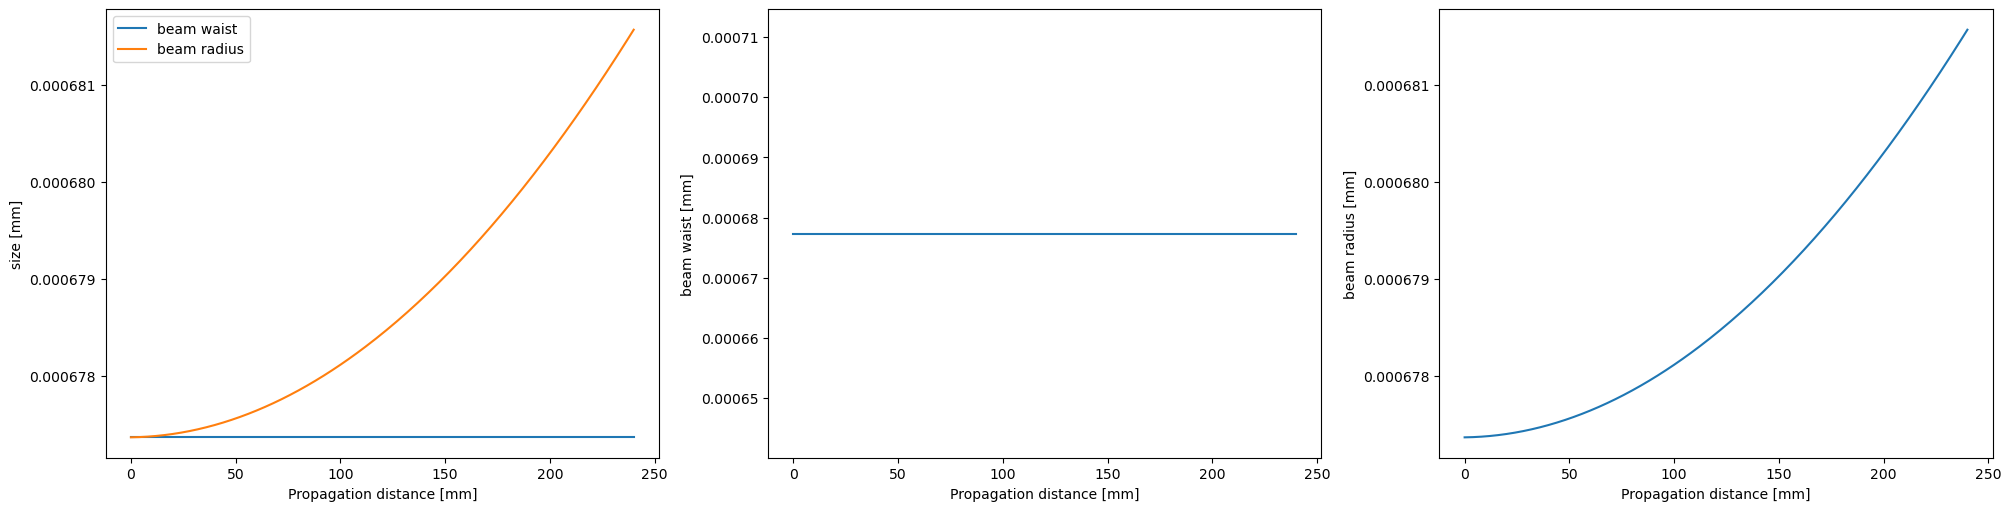

In [31]:
df = pd.read_csv("output.csv")
fig, axes = plt.subplots(1,3, figsize=(20,5), constrained_layout=True)

axes[0].plot(np.arange(0, len(df)), df["beam waist"], label="beam waist")
axes[0].plot(np.arange(0, len(df)), df["beam radius"], label="beam radius")
axes[0].set_ylabel("size [mm]")
axes[0].set_xlabel("Propagation distance [mm]")
axes[0].legend()

axes[1].plot(np.arange(0, len(df)), df["beam waist"])
axes[1].set_ylabel("beam waist [mm]")
axes[1].set_xlabel("Propagation distance [mm]")

axes[2].plot(np.arange(0, len(df)), df["beam radius"])
axes[2].set_ylabel("beam radius [mm]")
axes[2].set_xlabel("Propagation distance [mm]")

plt.show()

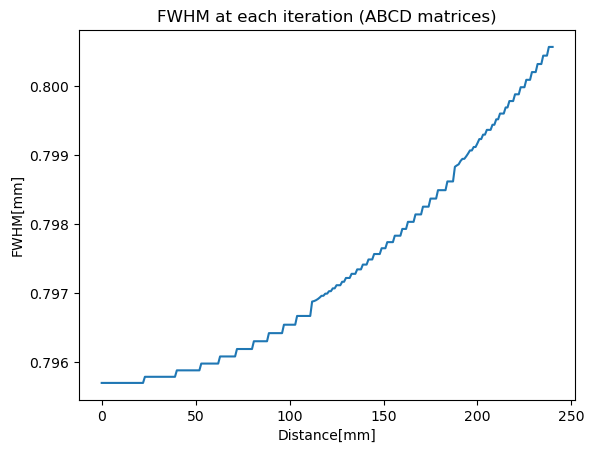

In [12]:
fwhm = []
length = pow(2,10)
width = 1000e-6
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
k = 2*np.pi * n0 / lambda_0
q0 = df.iloc[0]["q param real"] + 1j*df.iloc[0]["q param imag"]
# y = np.linspace(-width/2, width/2, length)
for i in range(0,df.index.size):
    q = df.iloc[i]["q param real"] + 1j*df.iloc[i]["q param imag"]
    amp = (amp_0 * q0 /q) * np.exp(-1j*k*(q.real - q0.real))
    Y = np.abs(amp * np.exp((-1j * k * (xx*xx + yy*yy)/(2*q))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real - 0.002 + ((xx*xx + yy*yy) / (2 * (q))))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real + ((x*x) / (2 * (q))))))**2             # FWHM 1D
    half_max = np.max(Y) / 2.0
    maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
    # dist = (maxIndex - left_idx)**2
    fwhm.append((np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length) #return the difference (full width)
fwhm = np.array(fwhm)*1e3
plt.plot(np.arange(0, df.index.size, 1), fwhm)
plt.ylabel("FWHM[mm]")
plt.xlabel("Distance[mm]")
plt.title("FWHM at each iteration (ABCD matrices)")
plt.show()


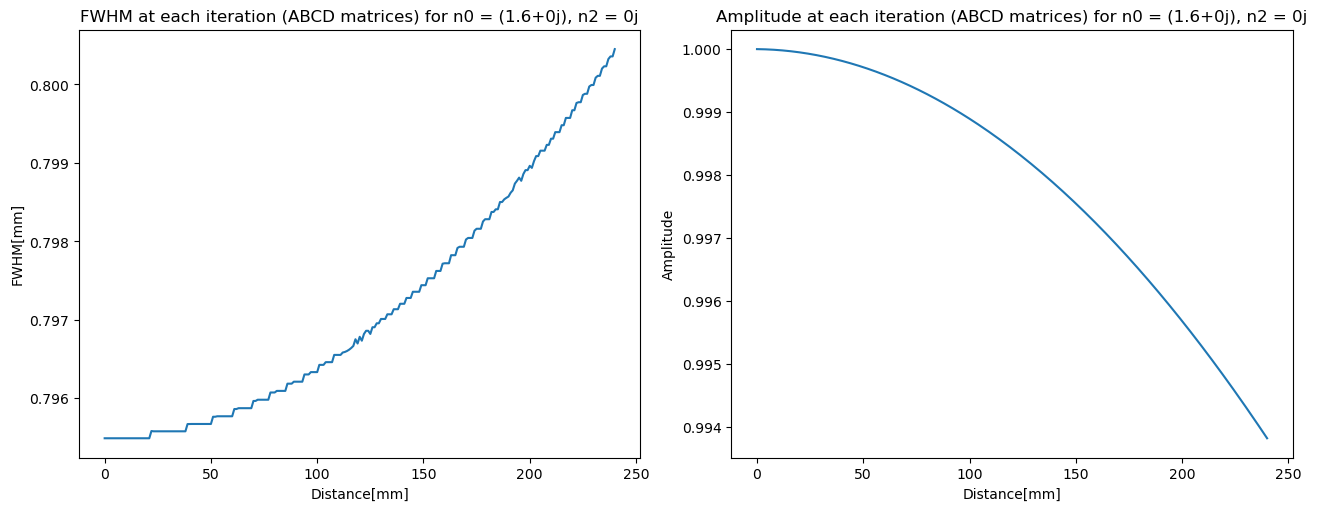

In [32]:
fwhm_refined = []
amps = []
length = pow(2,10)
width = 1000e-6
x = np.linspace(-width/2, width/2, length)
y = np.linspace(-width/2, width/2, length)
xx, yy = np.meshgrid(x,y)
k = 2*np.pi * n0 / lambda_0
gamma = np.sqrt(n2/n0)
# y = np.linspace(-width/2, width/2, length)
q0 = df.iloc[0]["q param real"] + 1j*df.iloc[0]["q param imag"]
for i in range(0,df.index.size):
    q = df.iloc[i]["q param real"] + 1j*df.iloc[i]["q param imag"]
    z = i*step_size
    A = np.cos(gamma*z)
    if gamma != 0:
        B = np.sin(gamma*z) / (n0*gamma)
    else:
        B = z/n0
    # amp = (amp_0 * q0 / q) * np.exp(-1j*k*z)
    amp = (amp_0 /(A + B*n0/q0)) * np.exp(-1j*k*z)
    Y = np.abs((amp * np.exp((-1j * k * (xx*xx + yy*yy)/(2*q))))**2)     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real - 0.002 + ((xx*xx + yy*yy) / (2 * (q))))))**2     # FWHM 2D
    # Y = np.abs((1/(q)) * np.exp(-1j * k * (q_real + ((x*x) / (2 * (q))))))**2             # FWHM 1D
    half_max = np.max(Y) / 2.0
    maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
    #find when function crosses line half_max (when sign of diff flips)
    #take the 'derivative' of signum(half_max - Y[])
    # d = np.sign(half_max - np.array(Y[0:-1])) - np.sign(half_max - np.array(Y[1:]))
    #plot(X[0:len(d)],d) #if you are interested
    #find the left and right most indexes
    left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
    # dist = (maxIndex - left_idx)**2
    fwhm_temp = (np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width/length
    fwhm_refined_temp = 1000
    for iter in range(10): 
        width_refined = 1.5*fwhm_temp
        x_refined = np.linspace(-width_refined/2, width_refined/2, length)
        y_refined = np.linspace(-width_refined/2, width_refined/2, length)
        xx_refined, yy_refined = np.meshgrid(x_refined,y_refined)
        Y = np.abs((amp * np.exp((-1j * k * (xx_refined*xx_refined + yy_refined*yy_refined)/(2*q))))**2)
        half_max = np.max(Y) / 2.0
        maxIndex = np.array(np.unravel_index(np.argmax(Y), Y.shape))
        left_idx = np.array(np.unravel_index(np.argmax(Y > half_max), Y.shape))
        fwhm_refined_temp = (np.sqrt(np.sum((maxIndex - left_idx)**2)))*2 * width_refined/length
        if np.abs(fwhm_temp - fwhm_refined_temp)/fwhm_refined_temp < 0.0001:
            # print(iter)
            break
        else:
            # print(iter, np.abs(fwhm_temp - fwhm_refined_temp)/fwhm_refined_temp)
            fwhm_temp = fwhm_refined_temp
            
    fwhm_refined.append(fwhm_refined_temp) #return the difference (full width)
    amps.append(amp)
fwhm_refined = np.array(fwhm_refined)*1e3
amps = np.abs(amps)

fig, axes = plt.subplots(1,2, figsize=(13,5), constrained_layout=True)
axes[0].plot(np.arange(0, df.index.size, 1), fwhm_refined)
axes[0].set_ylabel("FWHM[mm]")
axes[0].set_xlabel("Distance[mm]")
axes[0].set_title(f"FWHM at each iteration (ABCD matrices) for n0 = {n0}, n2 = {n2}")

axes[1].plot(np.arange(0, df.index.size, 1), amps)
axes[1].set_ylabel("Amplitude")
axes[1].set_xlabel("Distance[mm]")
axes[1].set_title(f"Amplitude at each iteration (ABCD matrices) for n0 = {n0}, n2 = {n2}")
plt.show()


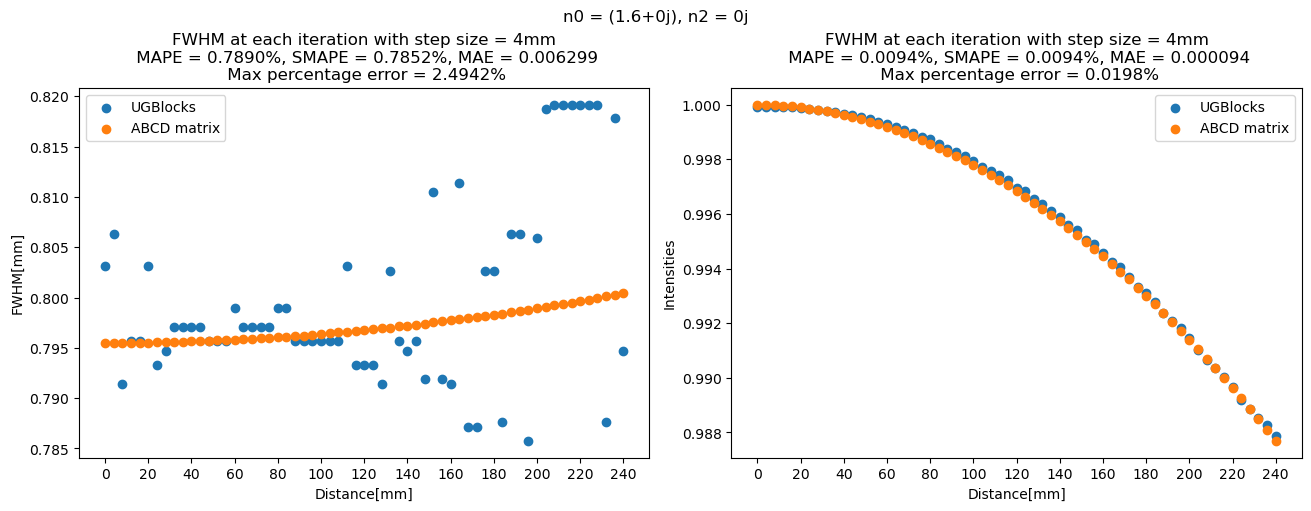

In [35]:
# fwhm_ugb = np.array([0.0820841,0.121976,0.166244,0.203626,0.243607,0.285258,0.328429,0.368583,0.409361,0.450372,0.49066])
fwhm_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/fwhms.csv', delimiter=',', dtype=float)
int_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/intensities.csv', delimiter=',', dtype=float)
# fwhm_ugb = np.loadtxt('/home/karthik/FAUbox/thesis/fwhm.csv', delimiter=',', dtype=float)
# file = open("/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat", 'r')
# file = open("/home/karthik/FAUbox/thesis/para.dat", 'r')
params_ugb = {}
with open("/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat") as f:
    lines = f.readlines()
    for item in lines:
        item = item.split()
        params_ugb[item[0]] = float(item[1])
n0_ugb = params_ugb["n0_real"] + 1j*params_ugb["n0_imag"]
n2_ugb = params_ugb["n2_real"] + 1j*params_ugb["n2_imag"]
end = params_ugb["zScreen"] + 1
# step = params["propagation_length"] * 1000
step_size = int(params_ugb["zScreen"]/params_ugb["steps"])
fwhm_abcd = fwhm_refined[0::step_size]
int_abcd = amps[0::step_size]**2
# fwhm_abcd = fwhms["values"][(fwhms["n0"] == n0_ugb) & (fwhms["n2"] == n2_ugb*1e6)].item()[0::step_size]
# int_abcd = fwhms["amplitudes"][(fwhms["n0"] == n0_ugb) & (fwhms["n2"] == n2_ugb*1e6)].item()[0::step_size]**2
fig, axes = plt.subplots(1,2, figsize=(13,5), constrained_layout=True)
axes[0].scatter(np.arange(0, end, step_size), fwhm_ugb[0::1], label="UGBlocks")
axes[0].scatter(np.arange(0, end, step_size), fwhm_abcd, label="ABCD matrix")
mape_fwhm = 100 * np.mean(np.abs(fwhm_ugb - fwhm_abcd) / fwhm_abcd)
smape_fwhm = 200 * np.mean(np.abs(fwhm_ugb - fwhm_abcd) / (np.abs(fwhm_ugb) + np.abs(fwhm_abcd)))
mae_fwhm = np.mean(np.abs(fwhm_ugb - fwhm_abcd))
maxPE_fwhm = 100 * np.max(np.abs(fwhm_ugb - fwhm_abcd) / fwhm_abcd)
axes[0].set_ylabel("FWHM[mm]")
axes[0].set_xlabel("Distance[mm]")
axes[0].set_xticks(np.arange(0, end, end//12))
axes[0].set_title(f"FWHM at each iteration with step size = {step_size}mm\n MAPE = {mape_fwhm:.4f}%, SMAPE = {smape_fwhm:.4f}%, MAE = {mae_fwhm:.6f}\n Max percentage error = {maxPE_fwhm:.4f}%")
axes[0].legend()

mape_intensity = 100 * np.mean(np.abs(int_ugb - int_abcd) / int_abcd)
smape_intensity = 200 * np.mean(np.abs(int_ugb - int_abcd) / (np.abs(int_ugb) + np.abs(int_abcd)))
mae_intensity = np.mean(np.abs(int_ugb - int_abcd))
maxPE_intensity = 100 * np.max(np.abs(int_ugb - int_abcd) / int_abcd)
axes[1].scatter(np.arange(0, end, step_size), int_ugb[0::1], label="UGBlocks")
axes[1].scatter(np.arange(0, end, step_size), (int_abcd), label="ABCD matrix")
axes[1].set_ylabel("Intensities")
axes[1].set_xlabel("Distance[mm]")
axes[1].set_xticks(np.arange(0, end, end//12))
axes[1].set_title("Intensities at each iteration")
axes[1].set_title(f"FWHM at each iteration with step size = {step_size}mm\n MAPE = {mape_intensity:.4f}%, SMAPE = {smape_intensity:.4f}%, MAE = {mae_intensity:.6f}\n Max percentage error = {maxPE_intensity:.4f}%")
axes[1].legend()

plt.suptitle(f"n0 = {n0_ugb}, n2 = {n2_ugb}")

plt.show()

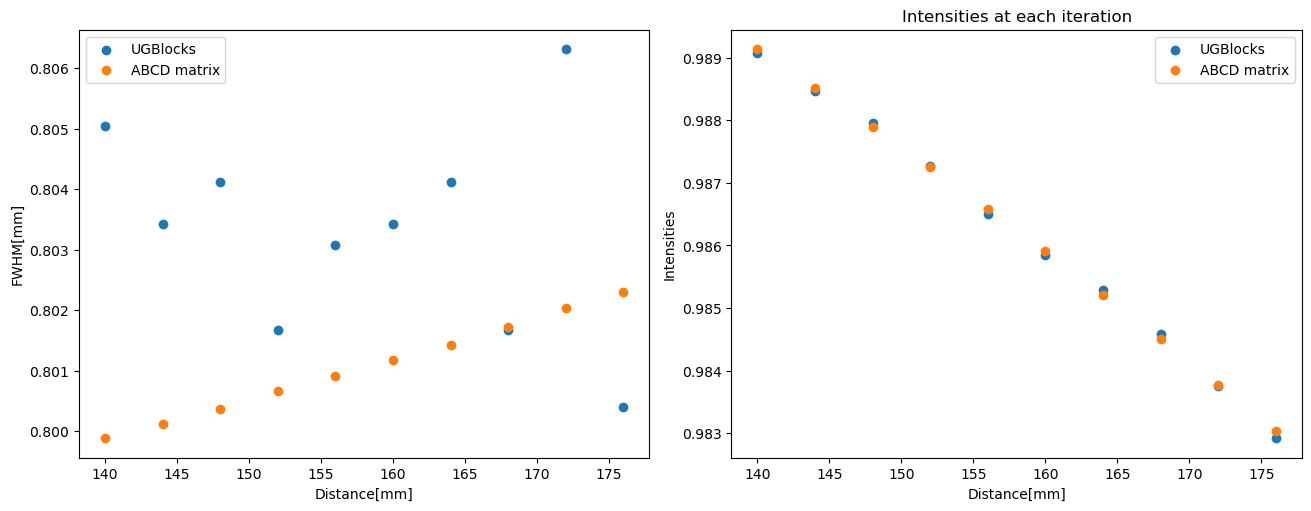

In [90]:
fig, axes = plt.subplots(1,2, figsize=(13,5), constrained_layout=True)
axes[0].scatter(np.arange(140, 180, step), fwhm_ugb[140//step:180//step], label="UGBlocks")
axes[0].scatter(np.arange(140, 180, step), fwhm_abcd[140//step:180//step], label="ABCD matrix")
axes[0].set_ylabel("FWHM[mm]")
axes[0].set_xlabel("Distance[mm]")
# axes[0].set_xticks(np.arange(0, end, end//12))
# axes[0].set_title(f"FWHM at each iteration with step size = {step}mm\n MAPE = {mape[step]:.4f}%, SMAPE = {smape[step]:.4f}%, MAE = {mae[step]:.6f}\n Max percentage error = {maxPE[step]:.4f}%")
axes[0].legend()

axes[1].scatter(np.arange(140, 180, step), int_ugb[140//step:180//step], label="UGBlocks")
axes[1].scatter(np.arange(140, 180, step), (int_abcd[140//step:180//step] ), label="ABCD matrix")
axes[1].set_ylabel("Intensities")
axes[1].set_xlabel("Distance[mm]")
# axes[1].set_xticks(np.arange(0, end, end//12))
axes[1].set_title("Intensities at each iteration")
axes[1].legend()

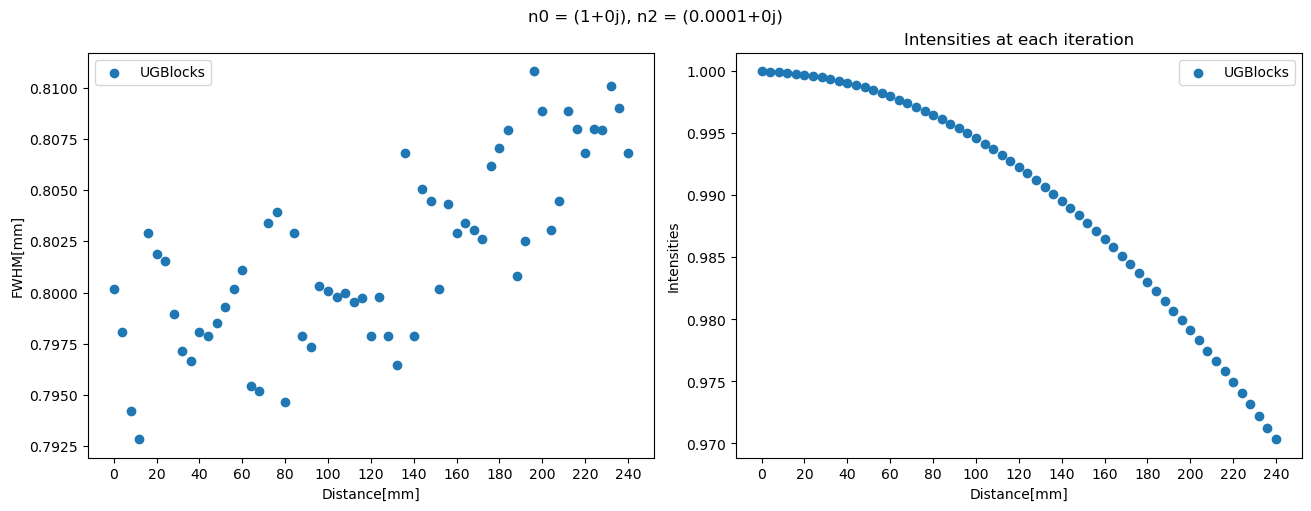

In [14]:
fwhm_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/fwhms.csv', delimiter=',', dtype=float)
int_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/intensities.csv', delimiter=',', dtype=float)
params_ugb = {}
with open("/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat") as f:
    lines = f.readlines()
    for item in lines:
        item = item.split()
        params_ugb[item[0]] = float(item[1])
n0_ugb = params_ugb["n0_real"] + 1j*params_ugb["n0_imag"]
n2_ugb = params_ugb["n2_real"] + 1j*params_ugb["n2_imag"]
end = params["propagation_length"]*(params["iterations"]+1) * 1000
step = int(params_ugb["zScreen"])
fig, axes = plt.subplots(1,2, figsize=(13,5), constrained_layout=True)
axes[0].scatter(np.arange(0, end, step), fwhm_ugb[0::1], label="UGBlocks")
axes[0].set_ylabel("FWHM[mm]")
axes[0].set_xlabel("Distance[mm]")
axes[0].set_xticks(np.arange(0, end, end//12))
axes[0].legend()

axes[1].scatter(np.arange(0, end, step), int_ugb[0::1], label="UGBlocks")
axes[1].set_ylabel("Intensities")
axes[1].set_xlabel("Distance[mm]")
axes[1].set_xticks(np.arange(0, end, end//12))
axes[1].set_title("Intensities at each iteration")
axes[1].legend()

plt.suptitle(f"n0 = {n0_ugb}, n2 = {n2_ugb}")

plt.show()

In [400]:
fwhms.loc[len(fwhms)] = [n0, n2, fwhm_refined.copy(), amps.copy()]

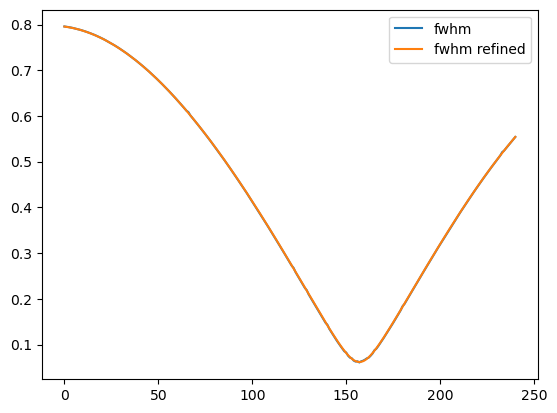

In [401]:
plt.plot(fwhm, label='fwhm')
plt.plot(fwhm_refined, label='fwhm refined')
plt.legend()
plt.show()

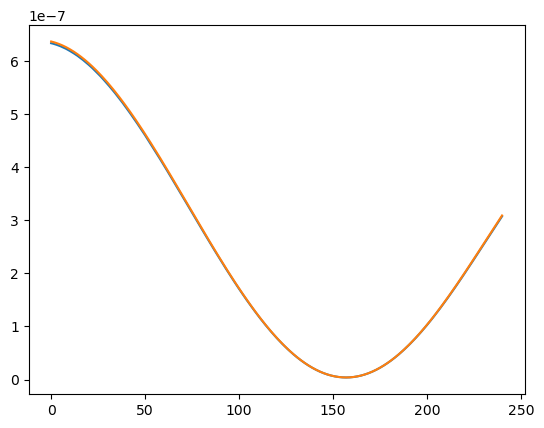

In [402]:
plt.plot((fwhm_refined/1e3)**2)
plt.plot(df["beam radius"]*(-2*np.log(0.5)))
plt.show()

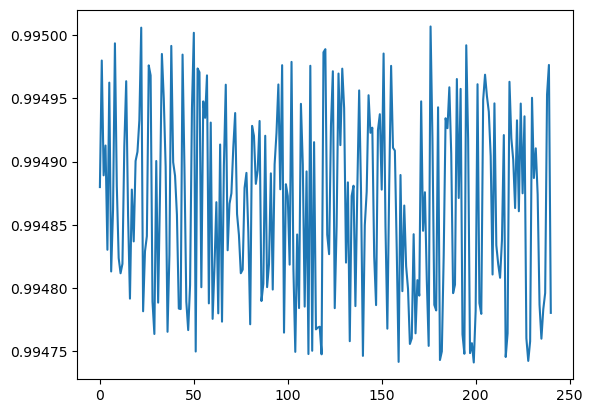

In [403]:
plt.plot((fwhm_refined/1e3)**2 / (df["beam radius"]*(-2*np.log(0.5))))
plt.show()

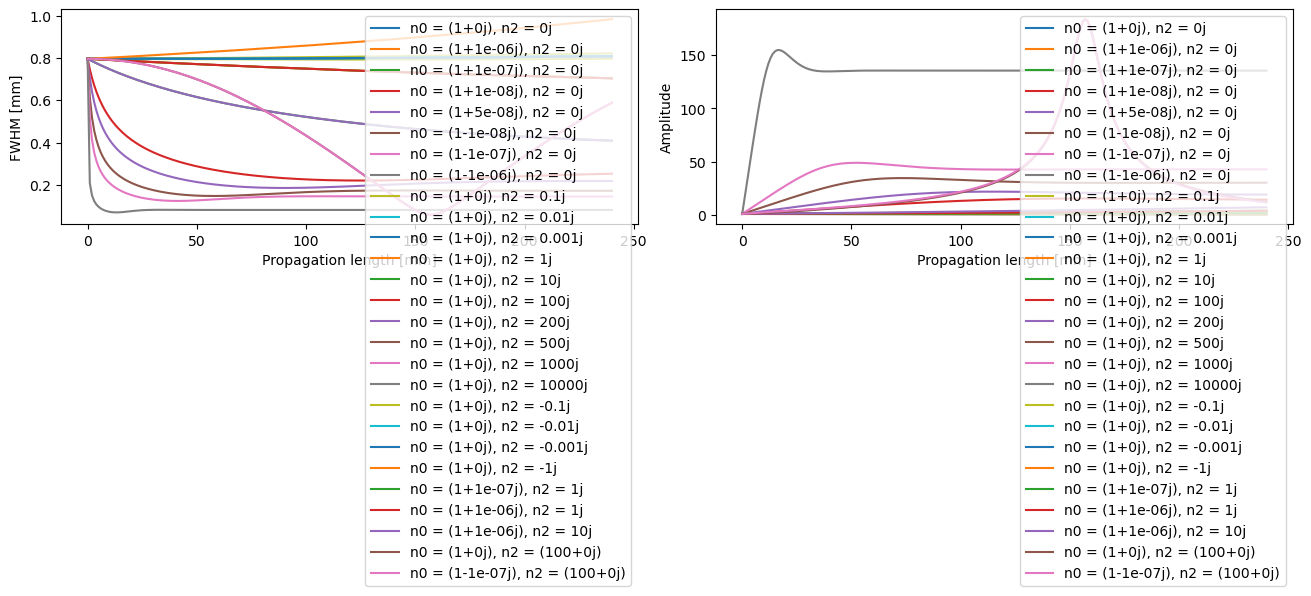

In [316]:
fig, axes = plt.subplots(1,2, figsize=(13,5), constrained_layout=True)
for i in range(len(fwhms)):
    axes[0].plot(fwhms.loc[i]["values"], label=f"n0 = {fwhms.loc[i]["n0"]}, n2 = {fwhms.loc[i]["n2"]}")
    axes[1].plot(fwhms.loc[i]["amplitudes"], label=f"n0 = {fwhms.loc[i]["n0"]}, n2 = {fwhms.loc[i]["n2"]}")
axes[0].set_xlabel("Propagation length [mm]")
axes[0].set_ylabel("FWHM [mm]")
axes[0].legend()
axes[1].set_xlabel("Propagation length [mm]")
axes[1].set_ylabel("Amplitude")
axes[1].legend()
plt.show()

In [296]:
fwhms.index[((np.imag(fwhms["n0"]) == 1e-6) | (np.imag(fwhms["n0"]) == 0))& ((np.imag(fwhms["n2"]) == 10) | (np.imag(fwhms["n2"]) == 0))].tolist()

[0, 1, 12, 24]

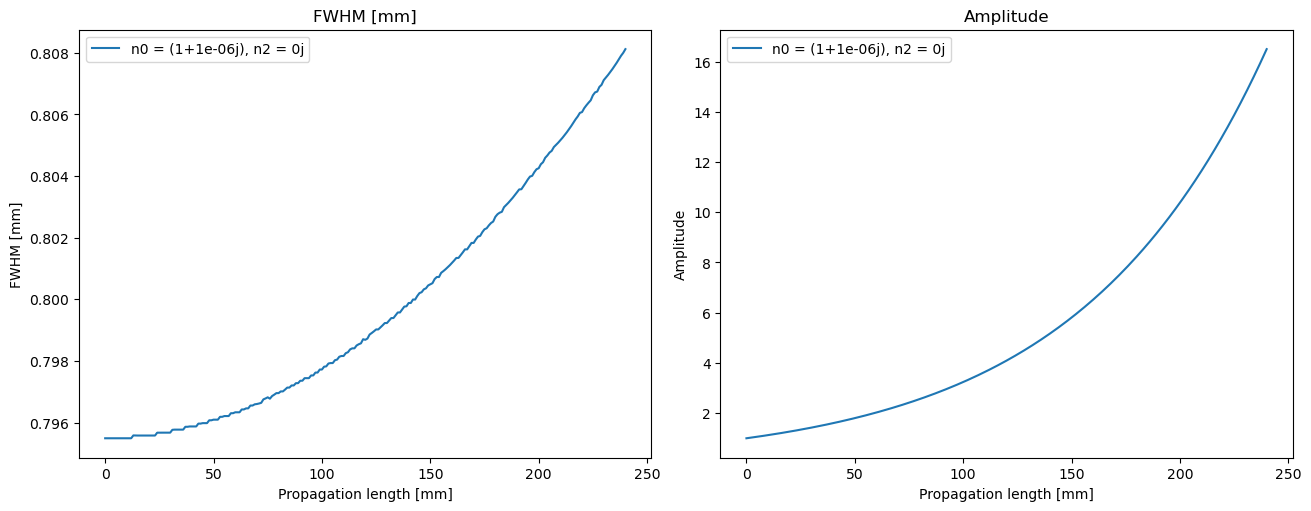

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(13,5), constrained_layout=True)
for i in fwhms.index[(np.real(fwhms["n2"]) == 0) & (np.imag(fwhms["n2"]) == 0) & (np.imag(fwhms["n0"]) == 1e-6)].tolist():
    axes[0].plot(fwhms.loc[i]["values"], label=f"n0 = {fwhms.loc[i]["n0"]}, n2 = {fwhms.loc[i]["n2"]}")
    axes[1].plot(fwhms.loc[i]["amplitudes"]**2, label=f"n0 = {fwhms.loc[i]["n0"]}, n2 = {fwhms.loc[i]["n2"]}")
axes[0].set_xlabel("Propagation length [mm]")
axes[0].set_ylabel("FWHM [mm]")
axes[0].set_title("FWHM [mm]")
axes[0].legend()
axes[1].set_xlabel("Propagation length [mm]")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Amplitude")
axes[1].legend()
plt.show()

In [407]:
fwhms["values"] = fwhms["values"].map(lambda val: np.array2string(val, separator=','))
fwhms["amplitudes"] = fwhms["amplitudes"].map(lambda val: np.array2string(val, separator=','))
fwhms.to_csv("fwhms_amps.csv", index=False)

In [174]:
np.imag(fwhms.loc[1]["n0"])

np.float64(1e-06)

In [177]:
fwhms.index[np.imag(fwhms["n0"])== 0].tolist()

[0, 8]

In [165]:
fwhms.columns

Index(['n0', 'n2', 'values', 'amplitudes'], dtype='str')

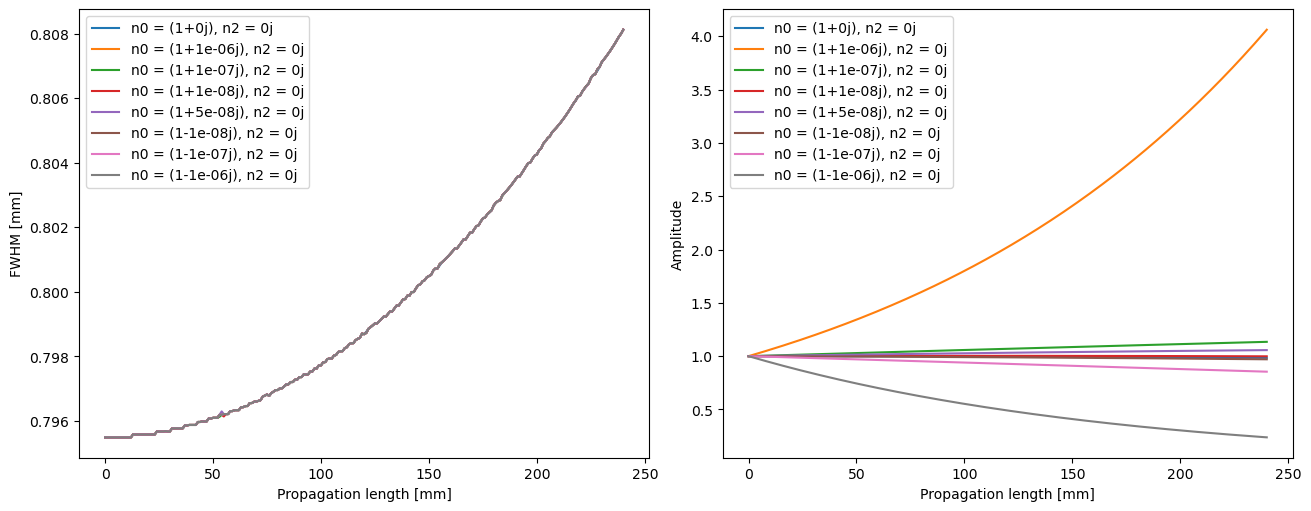

In [259]:
data = pd.read_csv("fwhms_amps.csv")
fig, axes = plt.subplots(1,2, figsize=(13,5), constrained_layout=True)
for i in range(len(data)):
    axes[0].plot(list(map(float, data.loc[i]["values"][1:-1].split())), label=f"n0 = {data.loc[i]["n0"]}, n2 = {data.loc[i]["n2"]}")
    axes[1].plot(list(map(float, data.loc[i]["amplitudes"][1:-1].split())), label=f"n0 = {data.loc[i]["n0"]}, n2 = {data.loc[i]["n2"]}")
axes[0].set_xlabel("Propagation length [mm]")
axes[0].set_ylabel("FWHM [mm]")
axes[0].legend()
axes[1].set_xlabel("Propagation length [mm]")
axes[1].set_ylabel("Amplitude")
axes[1].legend()
plt.show()

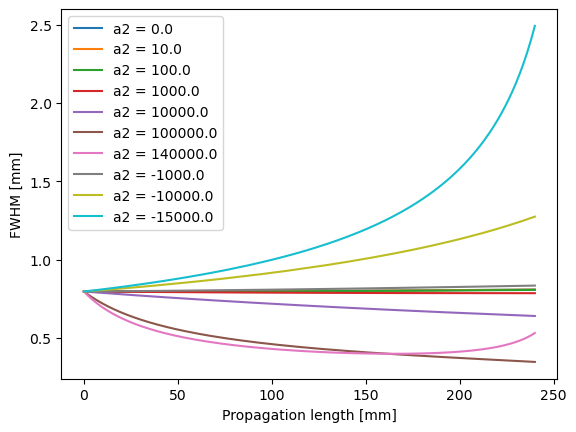

In [ ]:
# import pickle

# with open("saved_dict.pkl", "wb") as f:
#     pickle.dump(fwhms, f)
# with open("saved_dict.pkl", "rb") as f:
#     load_dict = pickle.load(f)
#     for key in load_dict.keys():
#         plt.plot(load_dict[key], label=f"a2 = {key}")
#     plt.xlabel("Propagation length [mm]")
#     plt.ylabel("FWHM [mm]")
#     plt.legend()
#     plt.show()

In [9]:
mape = {}
smape = {}
mae = {}
maxPE = {}

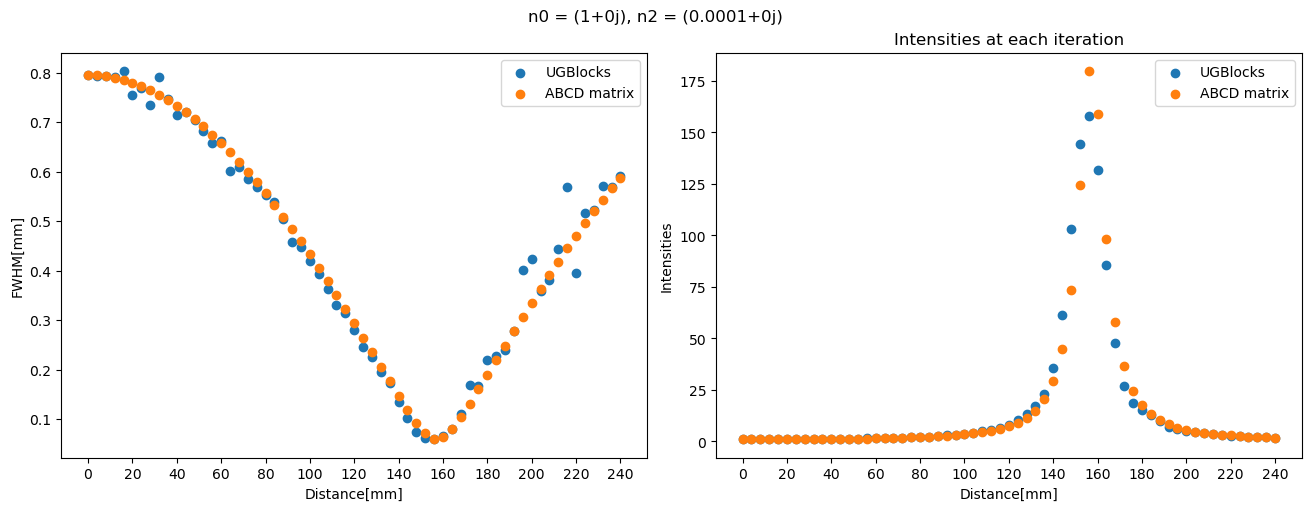

In [44]:
# fwhm_ugb = np.array([0.0820841,0.121976,0.166244,0.203626,0.243607,0.285258,0.328429,0.368583,0.409361,0.450372,0.49066])
fwhm_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/fwhms.csv', delimiter=',', dtype=float)
int_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/intensities.csv', delimiter=',', dtype=float)
# fwhm_ugb = np.loadtxt('/home/karthik/FAUbox/thesis/fwhm.csv', delimiter=',', dtype=float)
# file = open("/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat", 'r')
# file = open("/home/karthik/FAUbox/thesis/para.dat", 'r')
params_ugb = {}
with open("/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat") as f:
    lines = f.readlines()
    for item in lines:
        item = item.split()
        params_ugb[item[0]] = float(item[1])
n0_ugb = params_ugb["n0_real"] + 1j*params_ugb["n0_imag"]
n2_ugb = params_ugb["n2_real"] + 1j*params_ugb["n2_imag"]
end = params["propagation_length"]*(params["iterations"]+1) * 1000
# step = params["propagation_length"] * 1000
step = int(params_ugb["zScreen"])
fwhm_abcd = fwhm_refined[0::step]
int_abcd = amps[0::step]
# fwhm_abcd = fwhms["values"][(fwhms["n0"] == n0_ugb) & (fwhms["n2"] == n2_ugb*1e6)].item()[0::step]
# int_abcd = fwhms["amplitudes"][(fwhms["n0"] == n0_ugb) & (fwhms["n2"] == n2_ugb*1e6)].item()[0::step]
fig, axes = plt.subplots(1,2, figsize=(13,5), constrained_layout=True)
axes[0].scatter(np.arange(0, end, step), fwhm_ugb[0::1], label="UGBlocks")
axes[0].scatter(np.arange(0, end, step), fwhm_abcd, label="ABCD matrix")
# mape[step] = 100 * np.mean(np.abs(fwhm_ugb - fwhm_abcd) / fwhm_abcd)
# smape[step] = 200 * np.mean(np.abs(fwhm_ugb - fwhm_abcd) / (np.abs(fwhm_ugb) + np.abs(fwhm_abcd)))
# mae[step] = np.mean(np.abs(fwhm_ugb - fwhm_abcd))
# maxPE[step] = 100 * np.max(np.abs(fwhm_ugb - fwhm_abcd) / fwhm_abcd)
axes[0].set_ylabel("FWHM[mm]")
axes[0].set_xlabel("Distance[mm]")
axes[0].set_xticks(np.arange(0, end, end//12))
# axes[0].set_title(f"FWHM at each iteration with step size = {step}mm\n MAPE = {mape[step]:.4f}%, SMAPE = {smape[step]:.4f}%, MAE = {mae[step]:.6f}\n Max percentage error = {maxPE[step]:.4f}%")
axes[0].legend()

axes[1].scatter(np.arange(0, end, step), int_ugb[0::1], label="UGBlocks")
axes[1].scatter(np.arange(0, end, step), (int_abcd**2 ), label="ABCD matrix")
axes[1].set_ylabel("Intensities")
axes[1].set_xlabel("Distance[mm]")
axes[1].set_xticks(np.arange(0, end, end//12))
axes[1].set_title("Intensities at each iteration")
axes[1].legend()

plt.suptitle(f"n0 = {n0_ugb}, n2 = {n2_ugb}")

plt.show()

In [37]:
fwhm_old = fwhm_ugb

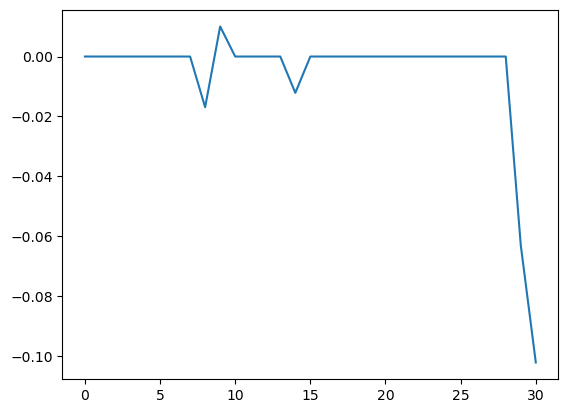

In [40]:
plt.plot(fwhm_ugb - fwhm_old)

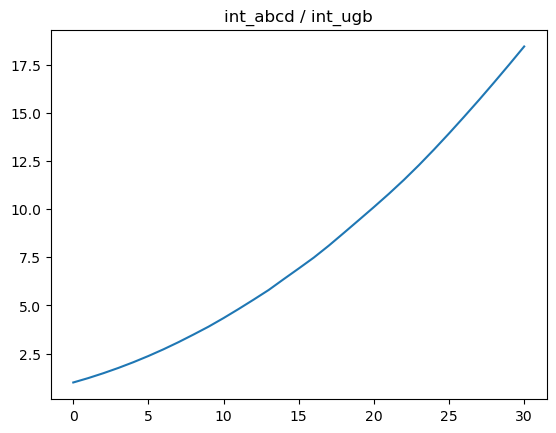

In [85]:
plt.plot((int_abcd**2 / int_ugb)[0:])
plt.title("int_abcd / int_ugb")
plt.show()

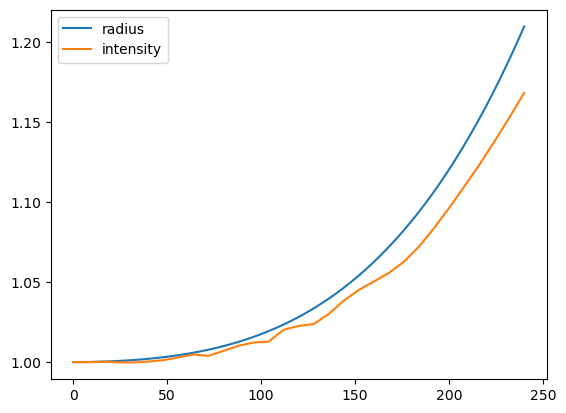

In [128]:
plt.plot((df["beam radius"]/df["beam waist"])**2, label = "radius")
plt.plot(np.arange(0, end, step),(int_abcd**2 / int_ugb / np.abs(q[0]/q[0::8])**2), label="intensity")
q = df["q param real"] + 1j*df["q param imag"]
# plt.plot(np.abs(q[0]/q)**2, label="q")
plt.legend()
plt.show()

In [105]:
(df["beam radius"]/df["beam waist"])[0:-1:8]

0       1
8       1
16      1
24      1
32      1
40      1
48      1
56      1
64      1
72      1
80      1
88      1
96      1
104     1
112     1
120     1
128     1
136     1
144     1
152     1
160     1
168     1
176     1
184     1
192   1.1
200   1.1
208   1.1
216   1.1
224   1.1
232   1.1
dtype: float64

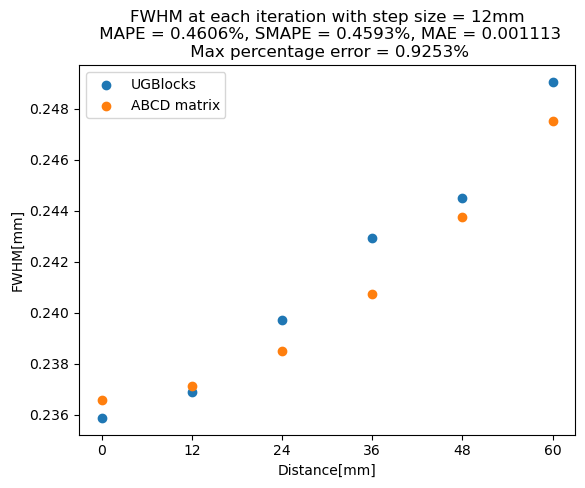

In [ ]:
# fwhm_ugb = np.array([0.0820841,0.121976,0.166244,0.203626,0.243607,0.285258,0.328429,0.368583,0.409361,0.450372,0.49066])
# fwhm_ugb = np.loadtxt('/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/fwhm.csv', delimiter=',', dtype=float)
fwhm_ugb = np.loadtxt('/home/karthik/FAUbox/thesis/fwhm.csv', delimiter=',', dtype=float)
# file = open("/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat", 'r')
# file = open("/home/karthik/FAUbox/thesis/para.dat", 'r')
params_ugb = {}
with open("/home/karthik/Desktop/FAU/Thesis/UGBlocks_V4_Oct_21_2025/program2D/para.dat") as f:
    lines = f.readlines()
    for item in lines:
        item = item.split()
        params_ugb[item[0]] = float(item[1])
end = params["propagation_length"]*(params["iterations"]+1) * 1000
# step = params["propagation_length"] * 1000
step = int(params_ugb["zScreen"])
plt.scatter(np.arange(0, end, step), fwhm_ugb[0::1], label="UGBlocks")
plt.scatter(np.arange(0, end, step), fwhm_refined[0::step], label="ABCD matrix")
mape[step] = 100 * np.mean(np.abs(fwhm_ugb - fwhm_refined[0::step]) / fwhm_refined[0::step])
smape[step] = 200 * np.mean(np.abs(fwhm_ugb - fwhm_refined[0::step]) / (np.abs(fwhm_ugb) + np.abs(fwhm_refined[0::step])))
mae[step] = np.mean(np.abs(fwhm_ugb - fwhm_refined[0::step]))
maxPE[step] = 100 * np.max(np.abs(fwhm_ugb - fwhm_refined[0::step]) / fwhm_refined[0::step])
plt.ylabel("FWHM[mm]")
plt.xlabel("Distance[mm]")
plt.xticks(np.arange(0, end, step))
plt.title(f"FWHM at each iteration with step size = {step}mm\n MAPE = {mape[step]:.4f}%, SMAPE = {smape[step]:.4f}%, MAE = {mae[step]:.6f}\n Max percentage error = {maxPE[step]:.4f}%")
plt.legend()
plt.show()

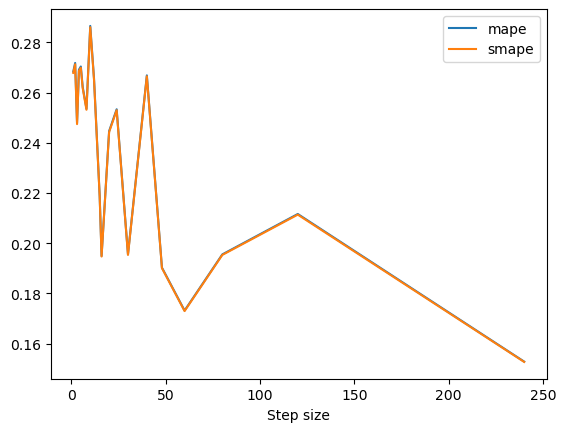

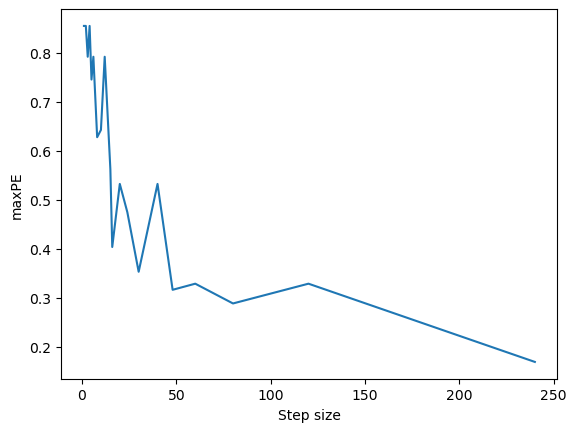

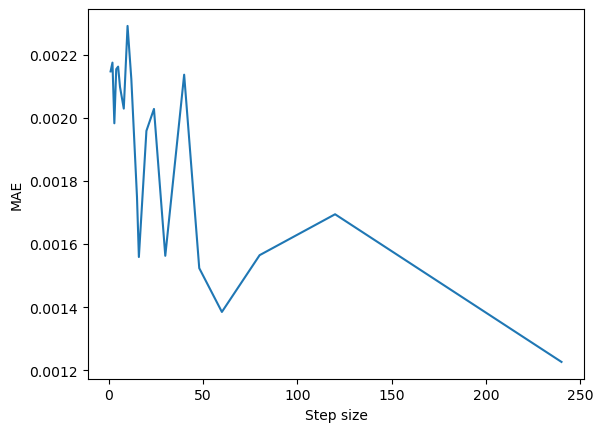

In [229]:
lists = sorted(mape.items())
x, y = zip(*lists)
plt.plot(x, y, label = "mape")
lists = sorted(smape.items())
x, y = zip(*lists)
plt.plot(x, y, label = "smape")
plt.legend()
plt.xlabel("Step size")
plt.show()

lists = sorted(maxPE.items())
x, y = zip(*lists)
plt.plot(x, y)
plt.xlabel("Step size")
plt.ylabel("maxPE")
plt.show()

lists = sorted(mae.items())
x, y = zip(*lists)
plt.plot(x, y)
plt.xlabel("Step size")
plt.ylabel("MAE")
plt.show()